In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

### Holi mocks

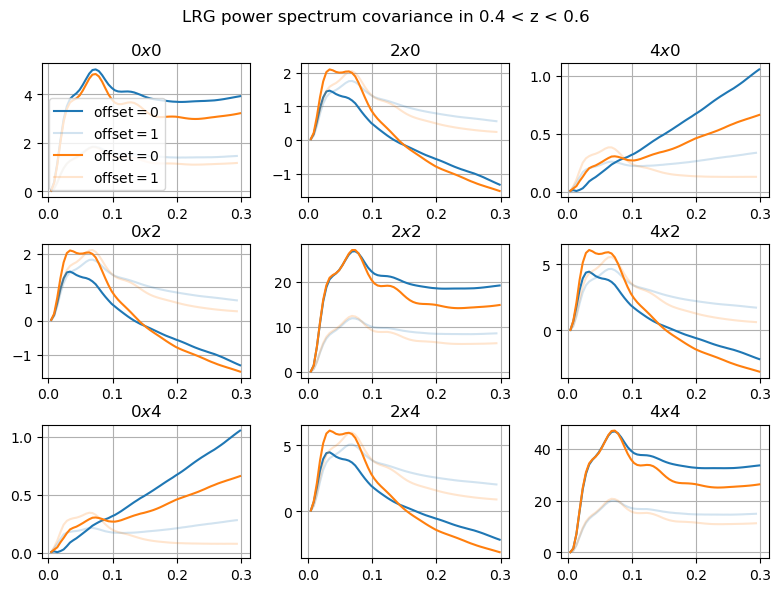

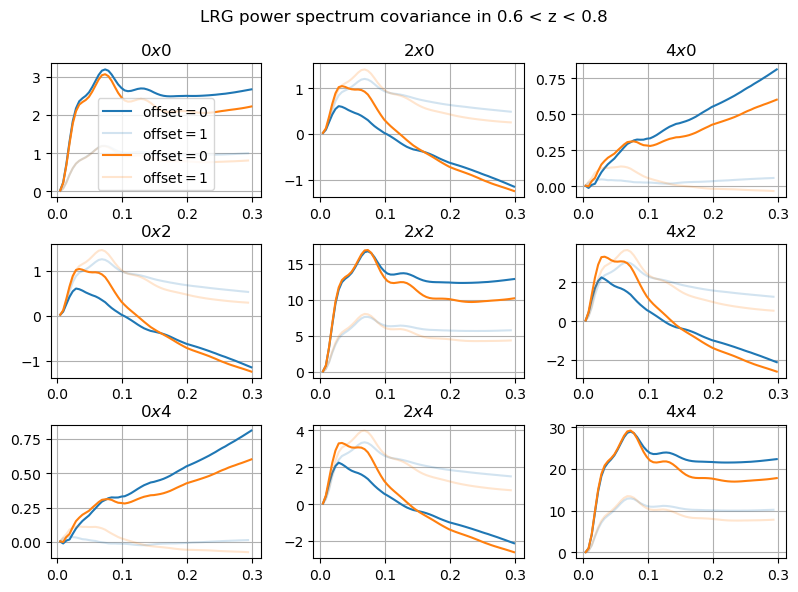

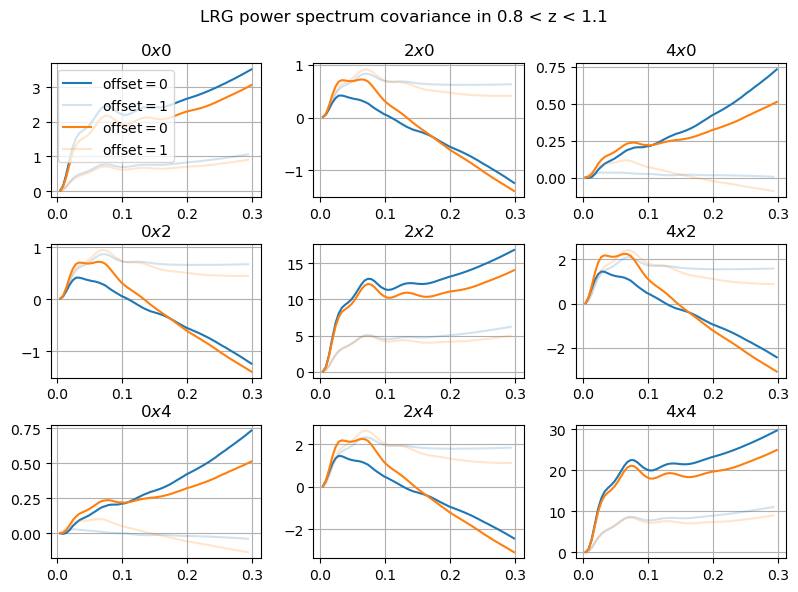

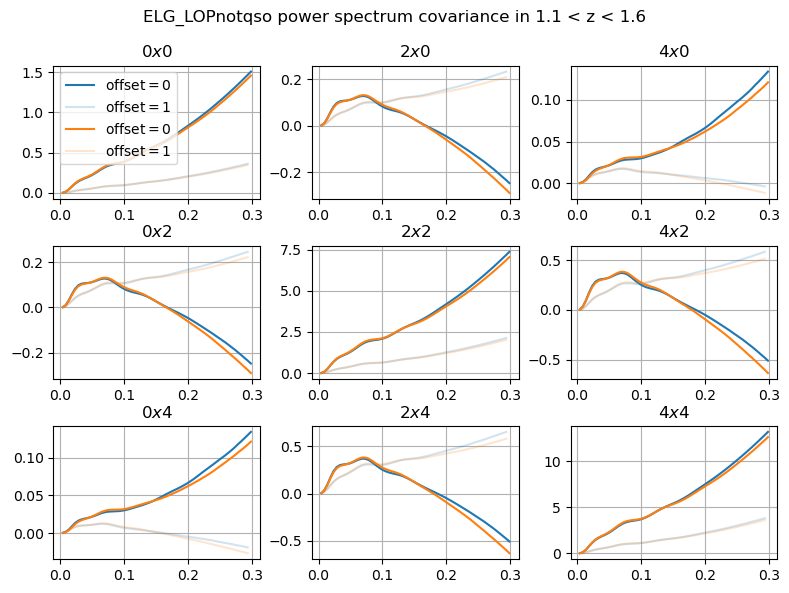

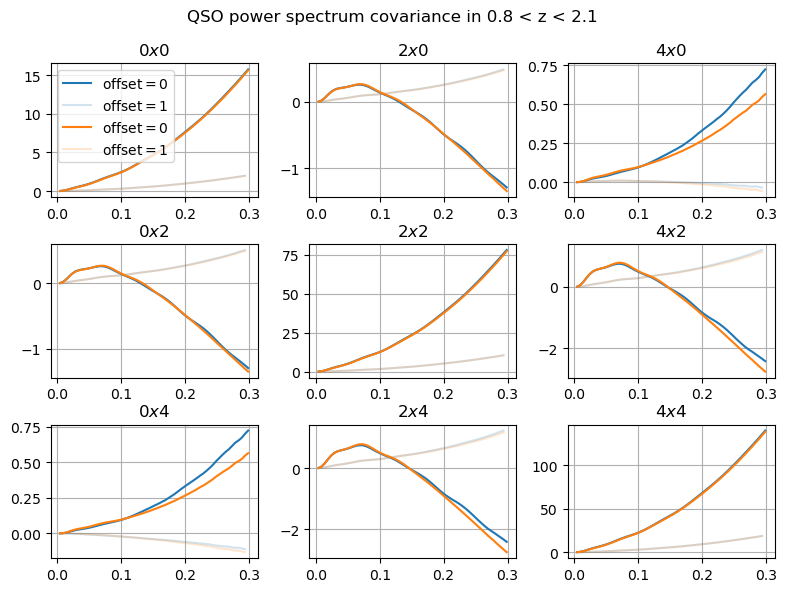

In [2]:
region = 'GCcomb'
version = 'holi-v3-altmtl'
tracers = [('LRG', (0.4, 0.6)), ('LRG', (0.6, 0.8)), ('LRG', (0.8, 1.1)), ('ELG_LOPnotqso', (1.1, 1.6)), ('QSO', (0.8, 2.1))]
stats_dir = tools.base_stats_dir
all_mocks = {}

for tracer, zrange in tracers:
    kw_catalog = dict(imock=0, tracer=tracer, zrange=zrange, version=version, weight='default-FKP', region=region)
    fn = tools.get_stats_fn(kind='covariance_mesh2_spectrum_poles', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog)
    covariance_analytic = types.read(fn).at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    fn = tools.get_stats_fn(kind='covariance_recon_mesh2_spectrum_poles', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog)
    covariance_analytic_recon = types.read(fn).at.observable.get(observables='spectrum2recon', tracers=(tools.get_simple_tracer(tracer),) * 2)

    observable = covariance_analytic.observable.select(k=slice(0, None, 5)).select(k=(0., 0.3))
    covariance_analytic = covariance_analytic.at.observable.match(observable)
    covariance_analytic_recon = covariance_analytic_recon.at.observable.match(observable)
    kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
    fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
    fig.suptitle(f'{tracer} power spectrum covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
    covariance_analytic_recon.plot_diag(**kw, fig=fig, color='C1', show=True)

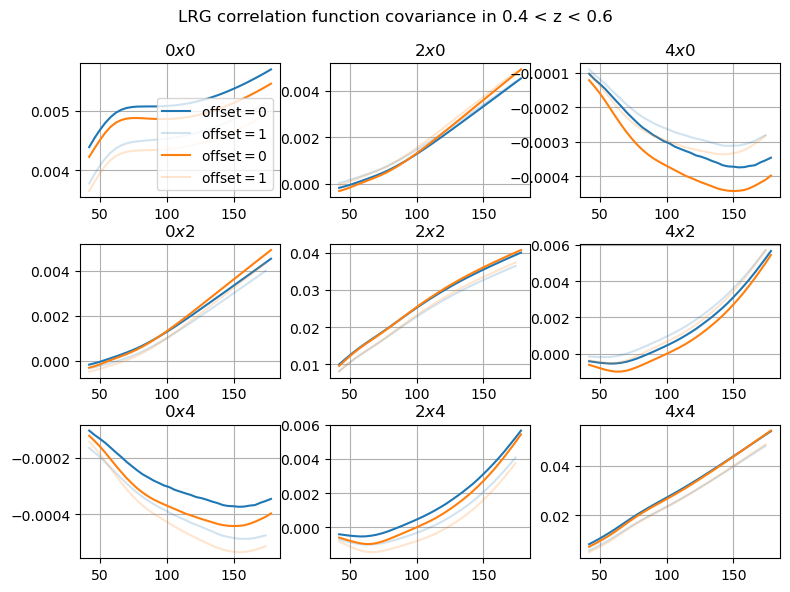

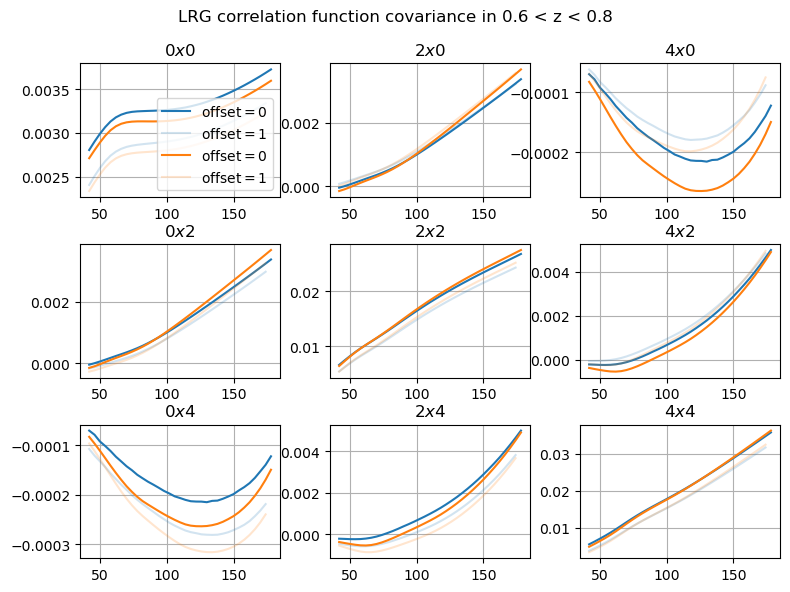

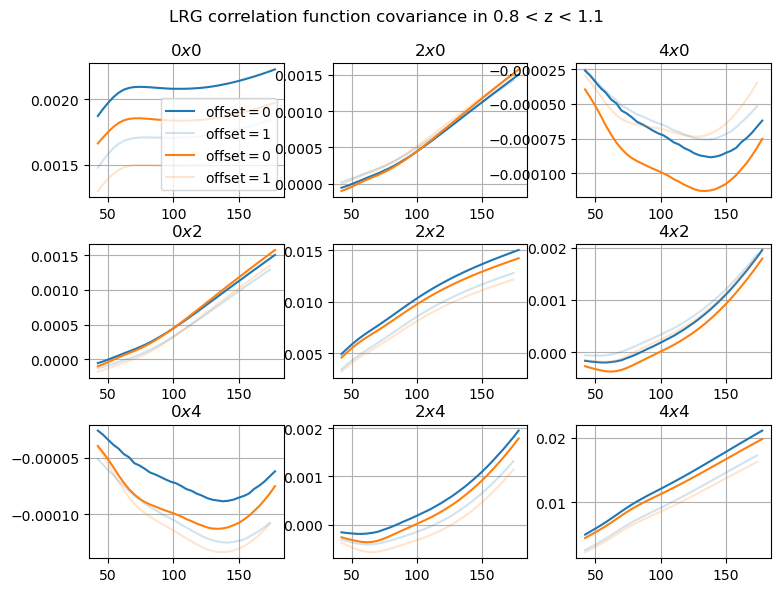

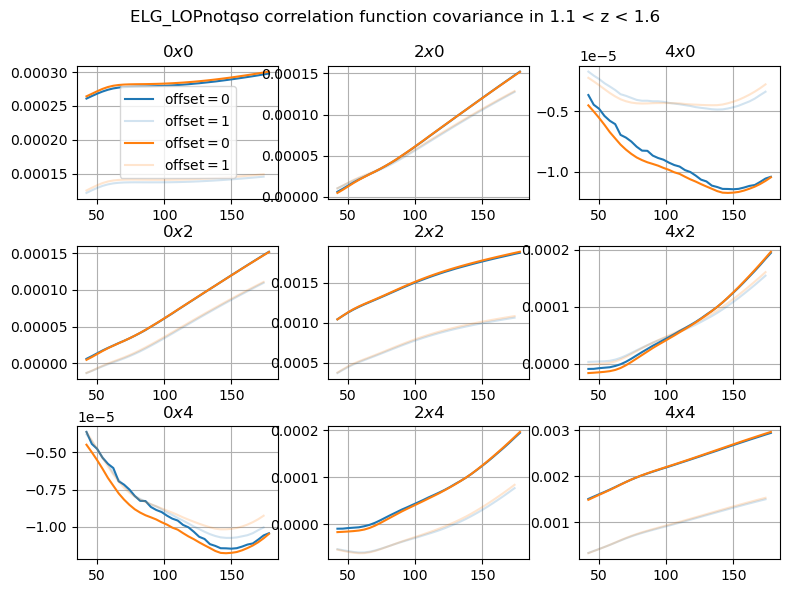

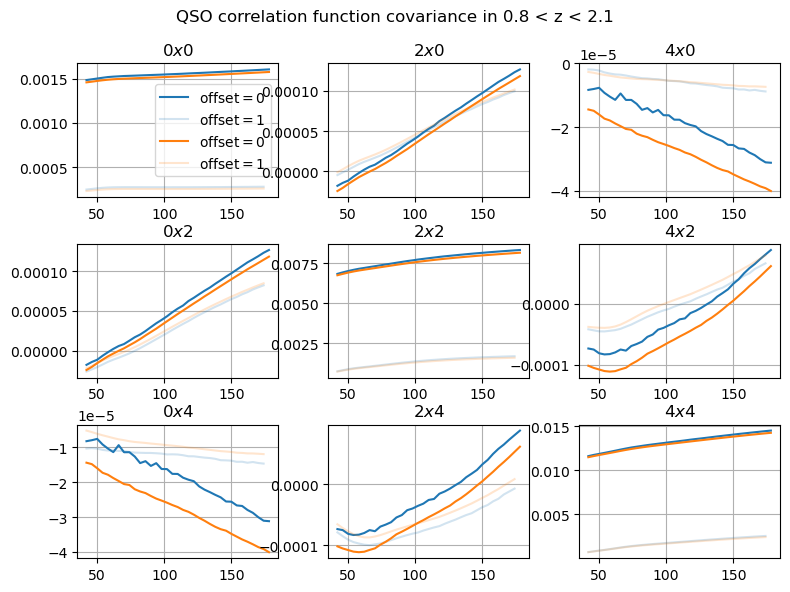

In [3]:
region = 'GCcomb'
version = 'holi-v3-altmtl'
tracers = [('LRG', (0.4, 0.6)), ('LRG', (0.6, 0.8)), ('LRG', (0.8, 1.1)), ('ELG_LOPnotqso', (1.1, 1.6)), ('QSO', (0.8, 2.1))]
stats_dir = tools.base_stats_dir

for tracer, zrange in tracers:
    kw_catalog = dict(imock=0, tracer=tracer, zrange=zrange, version=version, weight='default-FKP', region=region)
    fn = tools.get_stats_fn(kind='covariance_particle2_correlation', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog,
                            battrs=['poles'])
    covariance_analytic = types.read(fn).at.observable.get(observables='correlation2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    fn = tools.get_stats_fn(kind='covariance_recon_particle2_correlation', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog,
                            battrs=['poles'])
    covariance_analytic_recon = types.read(fn).at.observable.get(observables='correlation2recon', tracers=(tools.get_simple_tracer(tracer),) * 2)

    observable = covariance_analytic.observable.select(s=slice(0, None, 4)).select(s=(40., 180.))
    covariance_analytic = covariance_analytic.at.observable.match(observable)
    covariance_analytic_recon = covariance_analytic_recon.at.observable.match(observable)
    kw = dict(ytransform=lambda x, y: x**2 * y, offset=np.arange(2))
    fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
    fig.suptitle(f'{tracer} correlation function covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
    covariance_analytic_recon.plot_diag(**kw, fig=fig, color='C1', show=True)